# Mapper Topológico — Reto Ternium (Fase 3)
### Análisis de Circuitos Críticos de Abastecimiento mediante TDA

**Equipo:** MA2008B — Geometría y Topología para Ciencia de Datos  
**Objetivo:** Visualizar la estructura topológica del espacio logístico de Ternium usando el algoritmo Mapper, identificar regímenes operativos diferenciados y comunicar hallazgos relevantes sobre circuitos críticos para retroalimentar el modelo LNO.

---

### Flujo del Notebook
1. Instalación y carga de librerías
2. Carga y preprocesamiento de datos
3. Ingeniería de características (variables propuestas en Actividad 2)
4. Reducción de dimensionalidad (UMAP como lente para Mapper)
5. **Mapper principal** — grafo con múltiples etiquetas de color
6. Análisis cuantitativo de pureza de nodos
7. Mapper segmentado por circuito crítico
8. Mapper por ventanas temporales (evolución del sistema)
9. Interpretación topológica y recomendaciones para el LNO

## 1. Instalación de Dependencias

In [2]:
# Instalar librerías de TDA y visualización
# NOTA: en este entorno (conda 'topo') ya están instaladas; en Colab se instalan la 1a vez.
# (Corregido: el paquete de PyPI es 'giotto-tda', no 'gtda' -> antes esa línea daba error.)
#pip install kmapper umap-learn ripser persim scikit-tda giotto-tda -q
print("✓ Instalación completada")

✓ Instalación completada


## 2. Importaciones

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TDA y Mapper
import kmapper as km
from kmapper import Cover
import umap
import networkx as nx
from ripser import ripser
from persim import plot_diagrams

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Utilidades
from IPython.display import IFrame, display, HTML
import json

print("✓ Librerías importadas correctamente")
print(f"  kmapper: {km.__version__}")
print(f"  umap-learn: {umap.__version__}")

✓ Librerías importadas correctamente
  kmapper: 2.1.0
  umap-learn: 0.5.6


## 3. Carga y Preprocesamiento de Datos

> **Instrucción:** Sube el archivo Excel del reto (`Bajada Interplanta 2026.xlsx`) a tu Google Drive o directamente a Colab usando el panel de archivos. Ajusta la ruta abajo según corresponda.
>
> Si el archivo tiene múltiples hojas, el código lee automáticamente la hoja `GENERAL`.

In [4]:
# ──────────────────────────────────────────────────────────────
# AJUSTA ESTA RUTA al archivo real antes de correr el notebook
# Opción A: subida directa a Colab
FILE_PATH = "dataset_limpio_csv.csv"  # o .xlsx

# Opción B: desde Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = "/content/drive/MyDrive/ternium/Bajada_Interplanta_2026_limpio.csv"
# ──────────────────────────────────────────────────────────────

# Catálogo de líneas críticas (de la hoja 'Listado Líneas')
# ARREGLO #1b: esta lista ahora es solo un FALLBACK (si el CSV no trajera la flag).
# ANTES estaba incompleta (~21 de 80) y con 'MP Galvanizado III' DUPLICADA. Se quita
# el duplicado. El cruce real de criticidad lo trae ya el dataset limpio (ARREGLO #1).
LINEAS_CRITICAS = [
    "Runway Decapado", "Entrada Decapado 2", "MP CSI Apodaca Horizontal",
    "MP Galvanizado III", "Lavado", "Decapado", "MP Galvanizado I",
    "MP CSI Apodaca Vertical", "Nave Customizados MP", "MP Nogalar 3",
    "MP Galvanizado", "MP CSC Acabados", "MP CSI SLP", "MP Decapado 3",
    "Caliente", "Patio Norte de Enfriamiento", "Nave 6 Ojo Horizontal",
    "Nave 5 Ojo Horizontal", "Thyssenkrupp SLP",
    "THYSSENKRUPP", "POSCO MPPC"
    # ← Completa con las 80 líneas del catálogo de Ternium
]


def cargar_datos(file_path, lineas_criticas):
    """
    Carga el dataset de Ternium (CSV o Excel) y aplica el preprocesamiento
    definido en la Actividad 2: conversión de fechas, cálculo de tiempos,
    flags de línea crítica y viaje incompleto.
    """
    print(f"Cargando datos desde: {file_path}")

    # ── Lectura ──
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path, low_memory=False)
    else:
        # Excel con múltiples hojas → leer GENERAL
        xl = pd.ExcelFile(file_path)
        hoja = 'GENERAL' if 'GENERAL' in xl.sheet_names else xl.sheet_names[0]
        print(f"  Leyendo hoja: '{hoja}'")
        df = pd.read_excel(file_path, sheet_name=hoja)

    print(f"  Filas originales: {len(df):,} | Columnas: {df.shape[1]}")

    # ── Columnas de fecha → datetime ──
    cols_fecha = ['FECHA_ALTA_REMITO', 'FECHA_SALIDA_ORIGEN',
                  'FECHA_LLEGADA_DESTINO', 'FECHA_PRIMER_PROGRAMACION',
                  'FECHA_ALTA_VIAJE', 'FECHA_ALTA_ORDEN']
    for col in cols_fecha:
        if col in df.columns:
            # Si el valor es numérico (Excel serial), convertirlo
            if df[col].dtype in [np.float64, np.int64]:
                df[col] = pd.to_datetime(
                    df[col] - 25569, unit='D', origin='1970-01-01',
                    errors='coerce'
                )
            else:
                df[col] = pd.to_datetime(df[col], errors='coerce')

    # ── Tiempo de tránsito en horas ──
    if 'FECHA_SALIDA_ORIGEN' in df.columns and 'FECHA_LLEGADA_DESTINO' in df.columns:
        df['TIEMPO_TRANSITO_H'] = (
            df['FECHA_LLEGADA_DESTINO'] - df['FECHA_SALIDA_ORIGEN']
        ).dt.total_seconds() / 3600
    elif 'TIEMPO_TRANSITO_H' not in df.columns:
        raise ValueError("No se encontraron columnas de fecha para calcular TIEMPO_TRANSITO_H")

    # ============================ ARREGLO #2: limpieza del tiempo ============================
    # ANTES: los tiempos < 0 y > 200 h se ponian en NaN y MAS ADELANTE (celda de matriz X) se
    #        imputaban con la mediana. Eso dejaba ~57% de los puntos con el MISMO valor (2.02 h)
    #        -> un REGIMEN ARTIFICIAL que dominaba el grafo Mapper.
    #   df.loc[df['TIEMPO_TRANSITO_H'] < 0, 'TIEMPO_TRANSITO_H'] = np.nan
    #   df.loc[df['TIEMPO_TRANSITO_H'] > 200, 'TIEMPO_TRANSITO_H'] = np.nan
    # AHORA: DESCARTAMOS (no imputamos) las filas con tiempo no valido:
    #        - t <= 0  -> error de captura (llegada <= salida) = 41% de los datos
    #        - t > 168 h (1 semana) -> cola no plausible (la cola real llega a 8000 h)
    n_pre = len(df)
    df = df[(df['TIEMPO_TRANSITO_H'] > 0) & (df['TIEMPO_TRANSITO_H'] <= 168)].copy()
    print(f"  Tiempos no validos descartados: {n_pre - len(df):,} "
          f"({(n_pre - len(df)) / n_pre:.0%}) | mediana={df['TIEMPO_TRANSITO_H'].median():.1f} h")
    # ========================================================================================

    # ── Flag viaje incompleto ──
    # NOTA (consecuencia del ARREGLO #2): como ya descartamos los viajes sin tiempo
    # valido, los kept tienen ambas fechas -> VIAJE_INCOMPLETO queda en 0 en el set
    # analitico (un viaje sin tiempo no puede ubicarse en el espacio). Por eso
    # VIAJE_VULNERABLE se reduce de hecho a TIEMPO_ANOMALO.
    df['VIAJE_INCOMPLETO'] = (
        df['FECHA_SALIDA_ORIGEN'].isna() | df['FECHA_LLEGADA_DESTINO'].isna()
    ).astype(int)

    # ===================== ARREGLO #1: flag de linea critica =====================
    # ANTES: recalculaba ES_LINEA_CRITICA cruzando una lista hardcodeada (~21 lineas)
    #        contra la columna LÍNEA. Pero LÍNEA tiene CODIGOS ('DEC3_CHU'...), no
    #        nombres -> 0 coincidencias, y SOBREESCRIBIA la flag correcta. Resultado
    #        real en la corrida anterior: "Lineas criticas: 0 (0.0%)" (todo cero).
    #   col_linea = 'LÍNEA' if 'LÍNEA' in df.columns else 'LINEA'
    #   if col_linea in df.columns:
    #       df['ES_LINEA_CRITICA'] = df[col_linea].isin(lineas_criticas).astype(int)
    #   elif 'DESTINO' in df.columns:
    #       df['ES_LINEA_CRITICA'] = df['DESTINO'].isin(lineas_criticas).astype(int)
    #   else:
    #       df['ES_LINEA_CRITICA'] = 0
    # AHORA: usamos la flag ES_LINEA_CRITICA que YA viene en el dataset limpio (cruce
    #        correcto con el catalogo hecho en la Actividad 2 = 48,615 filas criticas).
    #        Solo si NO existiera, recaemos en el cruce por catalogo.
    if 'ES_LINEA_CRITICA' not in df.columns:
        base = 'LÍNEA' if 'LÍNEA' in df.columns else ('LINEA' if 'LINEA' in df.columns else 'DESTINO')
        df['ES_LINEA_CRITICA'] = df[base].isin(lineas_criticas).astype(int)
    df['ES_LINEA_CRITICA'] = df['ES_LINEA_CRITICA'].fillna(0).astype(int)
    # ============================================================================

    # ── Identificador de circuito (PLANTA_ORIGEN → DESTINO → NOMBRE_TIPO_CAMION) ──
    for col in ['PLANTA_ORIGEN', 'DESTINO', 'NOMBRE_TIPO_CAMION']:
        if col not in df.columns:
            df[col] = 'DESCONOCIDO'

    df['CIRCUITO'] = (
        df['PLANTA_ORIGEN'].fillna('?') + ' → ' +
        df['DESTINO'].fillna('?') + ' [' +
        df['NOMBRE_TIPO_CAMION'].fillna('?') + ']'
    )

    # ── Deduplicación exacta ──
    n_antes = len(df)
    df = df.drop_duplicates()
    print(f"  Duplicados eliminados: {n_antes - len(df):,}")
    print(f"  Dataset final: {len(df):,} filas")
    print(f"  Líneas críticas con tráfico: {df[df['ES_LINEA_CRITICA']==1]['DESTINO'].nunique()}")

    return df


df = cargar_datos(FILE_PATH, LINEAS_CRITICAS)
df.head(3)

Cargando datos desde: dataset_limpio_csv.csv
  Filas originales: 267,035 | Columnas: 58
  Tiempos no validos descartados: 153,975 (58%) | mediana=1.9 h
  Duplicados eliminados: 0
  Dataset final: 113,060 filas
  Líneas críticas con tráfico: 11


,C_SOCIEDAD,REMITO,FECHA_ALTA_REMITO,MESREMITO,DIAREMITO,FECHA_SOLICITADA,C_ID_ORDEN_CABECERA,REF_PEDIDO,LÍNEA,NUM_REF1,...,ANDEN_CD,GRUISTA_CD,C_CLIENTE_DESTINO_PRESENTE,DOCUMENTO_REFERENCIA_PRESENTE,REF_PEDIDO_PRESENTE,VIAJE_INCOMPLETO,TIEMPO_TRANSITO_H,LINEA_CRITICA_DESC,ES_LINEA_CRITICA,CIRCUITO
0,TM01,T00002615415,2026-01-20 17:13:00,1,20,2026-01-21 00:00:00,23496415,DEC3_CHU-260330-17,DEC3_CHU,260330,...,ZN CARGA A4,TermxIOTSvcUser,0,1,1,0,3.816667,Runway Decapado,1,Pesquería → Churubusco [Plataforma 3 ejes Neum...
1,TM01,T00002615415,2026-01-20 17:13:00,1,20,2026-01-25 11:20:00,23496859,DEC3_CHU,DEC3_CHU,NO_APLICA,...,ZN CARGA A4,TermxIOTSvcUser,0,1,1,0,3.816667,Runway Decapado,1,Pesquería → Churubusco [Plataforma 3 ejes Neum...
2,TM01,T00002613552,2026-01-17 11:17:00,1,17,2026-01-17 05:40:00,23470240,DEC3_CHU,DEC3_CHU,NO_APLICA,...,Anden 8 Playa Sur,terncalogisticabot,0,1,1,0,2.650000,Runway Decapado,1,Pesquería → Churubusco [Plataforma 3 Ejes Neum...


## 4. Ingeniería de Características

Variables derivadas propuestas en la Actividad 2, ahora materializadas:

In [5]:
def construir_features(df):
    """
    Materializa las variables derivadas propuestas en la Actividad 2.
    Retorna un DataFrame enriquecido.
    """
    df = df.copy()

    # ── 1. Tiempo de espera antes de salida (programación → salida) ──
    if 'FECHA_PRIMER_PROGRAMACION' in df.columns and 'FECHA_SALIDA_ORIGEN' in df.columns:
        df['TIEMPO_ESPERA_PROG_H'] = (
            df['FECHA_SALIDA_ORIGEN'] - df['FECHA_PRIMER_PROGRAMACION']
        ).dt.total_seconds() / 3600
        df.loc[df['TIEMPO_ESPERA_PROG_H'] < 0, 'TIEMPO_ESPERA_PROG_H'] = np.nan
        df.loc[df['TIEMPO_ESPERA_PROG_H'] > 500, 'TIEMPO_ESPERA_PROG_H'] = np.nan
    else:
        df['TIEMPO_ESPERA_PROG_H'] = np.nan

    # ── 2. Desviación temporal por circuito ──
    media_circuito = df.groupby('CIRCUITO')['TIEMPO_TRANSITO_H'].transform('median')
    df['DESVIACION_TEMPORAL'] = df['TIEMPO_TRANSITO_H'] - media_circuito

    # ── 3. Índice de anomalía temporal (IQR por circuito) ──
    q75 = df.groupby('CIRCUITO')['TIEMPO_TRANSITO_H'].transform(
        lambda x: x.quantile(0.75))
    q25 = df.groupby('CIRCUITO')['TIEMPO_TRANSITO_H'].transform(
        lambda x: x.quantile(0.25))
    iqr = q75 - q25
    umbral_superior = q75 + 1.5 * iqr
    df['TIEMPO_ANOMALO'] = (df['TIEMPO_TRANSITO_H'] > umbral_superior).astype(int)

    # ── 4. Viaje vulnerable (combinación de factores de riesgo) ──
    df['VIAJE_VULNERABLE'] = (
        (df['VIAJE_INCOMPLETO'] == 1) |
        (df['TIEMPO_ANOMALO'] == 1)
    ).astype(int)

    # ── 5. Indicador material pesado/ancho (>20 ton o >1500 mm) ──
    df['MATERIAL_CRITICO_FISICO'] = (
        (df.get('N_PESO_NETO', 0) > 20) | (df.get('N_ANCHO', 0) > 1500)
    ).astype(int)

    # ── 6. Codificación ordinal de tipo de camión ──
    le = LabelEncoder()
    df['ID_TIPO_CAMION_ENC'] = le.fit_transform(
        df['NOMBRE_TIPO_CAMION'].fillna('DESCONOCIDO'))

    # ── 7. Codificación ordinal de planta origen ──
    df['PLANTA_ORIGEN_ENC'] = le.fit_transform(
        df['PLANTA_ORIGEN'].fillna('DESCONOCIDO'))

    # ── 8. Codificación ordinal de destino ──
    df['DESTINO_ENC'] = le.fit_transform(
        df['DESTINO'].fillna('DESCONOCIDO'))

    # ── 9. Semana del mes como variable temporal ──
    if 'FECHA_SALIDA_ORIGEN' in df.columns:
        df['SEMANA_MES'] = df['FECHA_SALIDA_ORIGEN'].dt.isocalendar().week.astype(float)

    print("Features derivadas construidas:")
    nuevas = ['TIEMPO_ESPERA_PROG_H', 'DESVIACION_TEMPORAL', 'TIEMPO_ANOMALO',
              'VIAJE_VULNERABLE', 'MATERIAL_CRITICO_FISICO',
              'ID_TIPO_CAMION_ENC', 'PLANTA_ORIGEN_ENC', 'DESTINO_ENC']
    for f in nuevas:
        null_pct = df[f].isna().mean() * 100
        print(f"  {f:30s} | nulos: {null_pct:.1f}%")

    return df


df = construir_features(df)
print(f"\nViajes vulnerables: {df['VIAJE_VULNERABLE'].sum():,} ({df['VIAJE_VULNERABLE'].mean()*100:.1f}%)")
print(f"Tiempos anómalos:   {df['TIEMPO_ANOMALO'].sum():,} ({df['TIEMPO_ANOMALO'].mean()*100:.1f}%)")

Features derivadas construidas:
  TIEMPO_ESPERA_PROG_H           | nulos: 26.0%
  DESVIACION_TEMPORAL            | nulos: 0.0%
  TIEMPO_ANOMALO                 | nulos: 0.0%
  VIAJE_VULNERABLE               | nulos: 0.0%
  MATERIAL_CRITICO_FISICO        | nulos: 0.0%
  ID_TIPO_CAMION_ENC             | nulos: 0.0%
  PLANTA_ORIGEN_ENC              | nulos: 0.0%
  DESTINO_ENC                    | nulos: 0.0%

Viajes vulnerables: 13,079 (11.6%)
Tiempos anómalos:   13,079 (11.6%)


## 5. Preparación del Espacio de Features para TDA

In [6]:
# ── Variables numéricas para el análisis topológico ──
# Selección basada en los hallazgos de la Actividad 2
# ===================== ARREGLO #4 y #5: variables de la nube de puntos =====================
# ANTES: la nube TDA incluia:
#   - categoricas LABEL-ENCODED (ID_TIPO_CAMION_ENC, PLANTA_ORIGEN_ENC, DESTINO_ENC):
#     imponen un orden FALSO y distancias euclidianas sin sentido (DESTINO_ENC=5 no
#     esta "entre" 4 y 6) -> distorsionan la geometria del grafo. [#4]
#   - ES_LINEA_CRITICA y VIAJE_INCOMPLETO, que luego se usan como ETIQUETA de color y
#     de pureza -> CIRCULARIDAD (el grafo "separa" por algo que tu mismo metiste como
#     coordenada). [#5]
#   - TIEMPO_ESPERA_PROG_H tenia 35% de nulos (se imputaba -> mini-artefacto).
# FEATURES_TDA = ['TIEMPO_TRANSITO_H','N_PESO_NETO','N_ESPESOR','N_ANCHO',
#                 'ID_TIPO_CAMION_ENC','PLANTA_ORIGEN_ENC','DESTINO_ENC',
#                 'VIAJE_INCOMPLETO','ES_LINEA_CRITICA','TIEMPO_ESPERA_PROG_H',
#                 'DESVIACION_TEMPORAL']
# AHORA: solo variables CONTINUAS fisicas/temporales. Las categoricas y las flags de
#        negocio se usan UNICAMENTE como color del grafo, no como ejes.
FEATURES_TDA = [
    'TIEMPO_TRANSITO_H',      # Variable central del análisis
    'N_PESO_NETO',            # Carga del camión
    'N_ESPESOR',              # Dimensión física del material
    'N_ANCHO',                # Dimensión física del material
    'DESVIACION_TEMPORAL',    # Desvío del tiempo respecto a la mediana del circuito
]
# ==========================================================================================

# Solo conservar features que existen en el dataframe
features_disponibles = [f for f in FEATURES_TDA if f in df.columns]
print(f"Features disponibles para TDA: {len(features_disponibles)}")

# ── Submuestra para Mapper (el algoritmo es O(n²) en distancias) ──
# Recomendado: 5000-15000 puntos para datasets grandes
# Con 270k filas, usamos una muestra estratificada por criticidad
SAMPLE_SIZE = 8000  # Ajustar según RAM disponible en Colab

np.random.seed(42)

# Muestra estratificada: representación proporcional de críticos vs no críticos
criticos = df[df['ES_LINEA_CRITICA'] == 1]
no_criticos = df[df['ES_LINEA_CRITICA'] == 0]

n_criticos_sample = min(len(criticos), int(SAMPLE_SIZE * 0.35))  # oversample críticos
n_no_criticos_sample = SAMPLE_SIZE - n_criticos_sample

df_sample = pd.concat([
    criticos.sample(n=n_criticos_sample, random_state=42),
    no_criticos.sample(n=min(n_no_criticos_sample, len(no_criticos)), random_state=42)
]).reset_index(drop=True)

print(f"Muestra total: {len(df_sample):,} filas")
print(f"  Líneas críticas: {df_sample['ES_LINEA_CRITICA'].sum():,} ({df_sample['ES_LINEA_CRITICA'].mean()*100:.1f}%)")
print(f"  No críticas: {(1-df_sample['ES_LINEA_CRITICA']).sum():,}")

# ── Preparar matriz X (imputar nulos con mediana) ──
# NOTA (ARREGLO #2): TIEMPO_TRANSITO_H ya NO tiene nulos (las filas no validas se
# descartaron en cargar_datos), asi que ya no se inyecta el regimen artificial.
X_raw = df_sample[features_disponibles].copy()
for col in X_raw.columns:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

# ── Transformación logarítmica en variables con asimetría positiva ──
for col in ['TIEMPO_TRANSITO_H', 'N_PESO_NETO', 'TIEMPO_ESPERA_PROG_H']:
    if col in X_raw.columns:
        X_raw[col] = np.log1p(X_raw[col].clip(lower=0))

# ── Estandarización ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"\nMatriz X para TDA: {X_scaled.shape}")
# (print dinámico: TIEMPO_ESPERA_PROG_H ya no está en la nube tras el ARREGLO #4)
_logged = [c for c in ["TIEMPO_TRANSITO_H","N_PESO_NETO","TIEMPO_ESPERA_PROG_H"] if c in X_raw.columns]
print("Transformación log1p aplicada a:", ", ".join(_logged))

Features disponibles para TDA: 5
Muestra total: 8,000 filas
  Líneas críticas: 2,800 (35.0%)
  No críticas: 5,200

Matriz X para TDA: (8000, 5)
Transformación log1p aplicada a: TIEMPO_TRANSITO_H, N_PESO_NETO


## 6. Reducción de Dimensionalidad — Función Lente para Mapper

Probamos dos lentes y seleccionamos la que mejor revela estructura logística:

In [7]:
print("Calculando UMAP (lente principal)...")
# Parámetros calibrados para datos logísticos con múltiples regímenes
# n_neighbors alto (40) preserva estructura global
# min_dist moderado (0.4) permite ver transiciones entre regímenes
reducer_umap = umap.UMAP(
    n_components=2,
    n_neighbors=40,
    min_dist=0.4,
    metric='euclidean',
    random_state=42,
    verbose=False
)
X_umap = reducer_umap.fit_transform(X_scaled)
print(f"  UMAP calculado: {X_umap.shape}")

print("\nCalculando PCA (lente alternativa para comparación)...")
reducer_pca = PCA(n_components=2)
X_pca = reducer_pca.fit_transform(X_scaled)
varianza_explicada = reducer_pca.explained_variance_ratio_.sum()
print(f"  Varianza explicada por PC1+PC2: {varianza_explicada:.1%}")


# ── Visualización comparativa de lentes ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Funciones Lente para Mapper\n(color = línea crítica)',
             fontsize=13, fontweight='bold')

colores = df_sample['ES_LINEA_CRITICA'].values
cmap_critico = plt.cm.RdYlGn_r

for ax, emb, titulo in zip(axes,
                            [X_umap, X_pca,
                             np.column_stack([X_scaled[:, 0], X_scaled[:, 1]])],
                            ['UMAP (n_neighbors=40, min_dist=0.4)',
                             f'PCA (varianza={varianza_explicada:.1%})',
                             'Primeras 2 Features Estandarizadas']):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=colores, cmap=cmap_critico,
                    s=8, alpha=0.6)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

plt.colorbar(sc, ax=axes[-1], label='Línea Crítica (1=Sí)')
plt.tight_layout()
plt.savefig('lentes_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n→ Usaremos UMAP como lente principal para Mapper (preserva mejor la estructura global)")

Calculando UMAP (lente principal)...


KeyboardInterrupt: 

## 7. Mapper Principal — Grafo del Espacio Logístico

Configuración del Mapper adaptada a la naturaleza de los datos de Ternium:

In [ ]:
# ────────────────────────────────────────────────────
# PARÁMETROS DEL MAPPER
# Ajustados para datos logísticos con múltiples regímenes
# ────────────────────────────────────────────────────
N_CUBES = 12        # Número de intervalos en la cobertura
                    # Más cubos → mayor resolución, grafos más complejos
OVERLAP = 0.45      # Solapamiento entre cubos
                    # Mayor solapamiento → más conexiones entre regímenes
DBSCAN_EPS = 0.8    # Radio de vecindad del clustering local
                    # Menor eps → clusters más densos, más nodos
DBSCAN_MIN = 5      # Mínimo de puntos por cluster
# ────────────────────────────────────────────────────

mapper = km.KeplerMapper(verbose=1)

# La proyección usa UMAP como lente
lens = X_umap

# Construir el grafo
graph = mapper.map(
    lens,
    X_scaled,  # datos originales para el clustering local
    clusterer=DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN),
    cover=Cover(n_cubes=N_CUBES, perc_overlap=OVERLAP)
)

# ── Estadísticas del grafo ──
G = nx.Graph()
for nodo, vecinos in graph['links'].items():
    for v in vecinos:
        G.add_edge(nodo, v)

print("\n═══════════════════════════════════")
print("ESTADÍSTICAS DEL GRAFO MAPPER")
print("═══════════════════════════════════")
print(f"  Nodos:                {G.number_of_nodes()}")
print(f"  Aristas:              {G.number_of_edges()}")
print(f"  Componentes conexas:  {nx.number_connected_components(G)}")
if G.number_of_nodes() > 0:
    print(f"  Grado promedio:       {sum(dict(G.degree()).values())/G.number_of_nodes():.2f}")
    # Nodos hub (mayor conectividad)
    grados = sorted(G.degree(), key=lambda x: x[1], reverse=True)
    print(f"  Top-3 nodos hub:      {[n for n, d in grados[:3]]}")
print("═══════════════════════════════════")

KeplerMapper(verbose=1)
Mapping on data shaped (8000, 5) using lens shaped (8000, 2)

Creating 144 hypercubes.



Created 405 edges and 165 nodes in 0:00:00.333168.

═══════════════════════════════════
ESTADÍSTICAS DEL GRAFO MAPPER
═══════════════════════════════════
  Nodos:                165
  Aristas:              405
  Componentes conexas:  19
  Grado promedio:       4.91
  Top-3 nodos hub:      ['cube40_cluster0', 'cube27_cluster0', 'cube26_cluster0']
═══════════════════════════════════


In [ ]:
# ── Visualización interactiva coloreada por Tiempo de Tránsito ──
idx_tt = features_disponibles.index('TIEMPO_TRANSITO_H') if 'TIEMPO_TRANSITO_H' in features_disponibles else 0

mapper.visualize(
    graph,
    path_html="mapper_tiempo_transito.html",
    title="Ternium — Mapper: Espacio Logístico (color = log(Tiempo de Tránsito))",
    color_values=X_scaled[:, idx_tt],
    color_function_name="Tiempo de Tránsito (log-escala)",
    node_color_function=["mean", "std", "median", "max"]
)
display(IFrame('mapper_tiempo_transito.html', width=900, height=550))

Wrote visualization to: mapper_tiempo_transito.html


In [ ]:
# ── Visualización coloreada por Línea Crítica ──
mapper.visualize(
    graph,
    path_html="mapper_linea_critica.html",
    title="Ternium — Mapper: Espacio Logístico (color = Línea Crítica)",
    color_values=df_sample['ES_LINEA_CRITICA'].values.astype(float),
    color_function_name="Es Línea Crítica (1=Sí, 0=No)",
    node_color_function=["mean", "sum", "max"]
)
display(IFrame('mapper_linea_critica.html', width=900, height=550))

Wrote visualization to: mapper_linea_critica.html


In [ ]:
# ── Visualización coloreada por Viaje Vulnerable ──
mapper.visualize(
    graph,
    path_html="mapper_viaje_vulnerable.html",
    title="Ternium — Mapper: Espacio Logístico (color = Viaje Vulnerable)",
    color_values=df_sample['VIAJE_VULNERABLE'].values.astype(float),
    color_function_name="Viaje Vulnerable (tiempo anómalo o incompleto)",
    node_color_function=["mean", "sum"]
)
display(IFrame('mapper_viaje_vulnerable.html', width=900, height=550))

Wrote visualization to: mapper_viaje_vulnerable.html


In [ ]:
# ── Visualización coloreada por Tipo de Camión ──
mapper.visualize(
    graph,
    path_html="mapper_tipo_camion.html",
    title="Ternium — Mapper: Espacio Logístico (color = Tipo de Camión)",
    color_values=df_sample['ID_TIPO_CAMION_ENC'].values.astype(float),
    color_function_name="Tipo de Camión (codificado)",
    node_color_function=["mean", "std"]
)
display(IFrame('mapper_tipo_camion.html', width=900, height=550))

Wrote visualization to: mapper_tipo_camion.html


## 8. Análisis de Pureza de Nodos

¿Qué tan homogéneos son los nodos del grafo respecto a las etiquetas de negocio?

In [ ]:
def node_purity(graph_dict, labels, nombre_etiqueta='etiqueta'):
    """
    Calcula la pureza ponderada de los nodos del grafo Mapper
    respecto a una etiqueta dada.

    Pureza = fracción de la clase mayoritaria en cada nodo.
    Pureza ponderada = promedio ponderado por tamaño de nodo.
    """
    labels = np.array(labels)
    n_clases = len(np.unique(labels[~np.isnan(labels.astype(float))]))
    purities = []
    details = []

    for node, idx in graph_dict['nodes'].items():
        if len(idx) == 0:
            continue
        node_labels = labels[idx]
        # Para variables continuas, usar cuantiles
        if n_clases > 10:
            med = np.nanmedian(node_labels)
            std = np.nanstd(node_labels)
            details.append({
                'nodo': node, 'tamaño': len(idx),
                'mediana': med, 'std': std
            })
        else:
            counts = np.bincount(
                node_labels.astype(int).clip(0),
                minlength=int(labels.max()) + 1
            )
            purity = counts.max() / counts.sum()
            purities.append((len(idx), purity))
            details.append({
                'nodo': node, 'tamaño': len(idx),
                'pureza': purity, 'clase_dom': counts.argmax()
            })

    detail_df = pd.DataFrame(details)

    if purities:
        pur_pond = np.average(
            [p for _, p in purities],
            weights=[s for s, _ in purities]
        )
        print(f"  {nombre_etiqueta:35s} → Pureza ponderada: {pur_pond:.3f}")
        return pur_pond, detail_df.sort_values('pureza') if 'pureza' in detail_df else detail_df
    else:
        print(f"  {nombre_etiqueta:35s} → Variable continua")
        return None, detail_df


print("═══════════════════════════════════════════")
print("PUREZA DE NODOS POR ETIQUETA DE NEGOCIO")
print("═══════════════════════════════════════════")

etiquetas_negocio = {
    'Línea Crítica (1=Sí)':       df_sample['ES_LINEA_CRITICA'].values,
    'Viaje Vulnerable (1=Sí)':     df_sample['VIAJE_VULNERABLE'].values,
    'Viaje Incompleto (1=Sí)':     df_sample['VIAJE_INCOMPLETO'].values,
    'Tiempo Anómalo (1=Sí)':       df_sample['TIEMPO_ANOMALO'].values,
    'Planta Origen':               df_sample['PLANTA_ORIGEN_ENC'].values,
    'Tipo de Camión':              df_sample['ID_TIPO_CAMION_ENC'].values,
}

resultados_pureza = {}
for nombre, labels in etiquetas_negocio.items():
    pur, detalle = node_purity(graph, labels, nombre)
    resultados_pureza[nombre] = {'pureza': pur, 'detalle': detalle}

print("═══════════════════════════════════════════")

# ===================== ARREGLO #3: interpretacion honesta de la pureza =====================
# ANTES: "Pureza > 0.75 = nodos bien separados". ENGAÑOSO: para una binaria 70/30, 0.75
#        es casi la TASA BASE (la alcanza la clase mayoritaria SIN estructura). Ademas
#        antes salia 1.000 solo porque la etiqueta era constante por el bug #1.
# AHORA: comparamos la pureza contra la tasa base de cada etiqueta (lift = pureza - base).
#        Solo hay señal topologica real si la pureza SUPERA claramente la tasa base.
print("\nPureza vs tasa base (señal real solo si lift > 0):")
for nombre, labels in etiquetas_negocio.items():
    lab = np.array(labels, dtype=float)
    lab = lab[~np.isnan(lab)]
    vals, cnts = np.unique(lab, return_counts=True)
    pur = resultados_pureza[nombre]['pureza']
    if pur is not None and len(vals) <= 10:
        base = cnts.max() / cnts.sum()
        print(f"  {nombre:30s} pureza={pur:.3f} | base={base:.3f} | lift={pur - base:+.3f}")
# ==========================================================================================

═══════════════════════════════════════════
PUREZA DE NODOS POR ETIQUETA DE NEGOCIO
═══════════════════════════════════════════
  Línea Crítica (1=Sí)                → Pureza ponderada: 0.681
  Viaje Vulnerable (1=Sí)             → Pureza ponderada: 0.904
  Viaje Incompleto (1=Sí)             → Pureza ponderada: 1.000
  Tiempo Anómalo (1=Sí)               → Pureza ponderada: 0.904
  Planta Origen                       → Pureza ponderada: 0.597


  Tipo de Camión                      → Variable continua
═══════════════════════════════════════════

Pureza vs tasa base (señal real solo si lift > 0):
  Línea Crítica (1=Sí)           pureza=0.681 | base=0.650 | lift=+0.031
  Viaje Vulnerable (1=Sí)        pureza=0.904 | base=0.886 | lift=+0.019
  Viaje Incompleto (1=Sí)        pureza=1.000 | base=1.000 | lift=+0.000
  Tiempo Anómalo (1=Sí)          pureza=0.904 | base=0.886 | lift=+0.019
  Planta Origen                  pureza=0.597 | base=0.368 | lift=+0.228


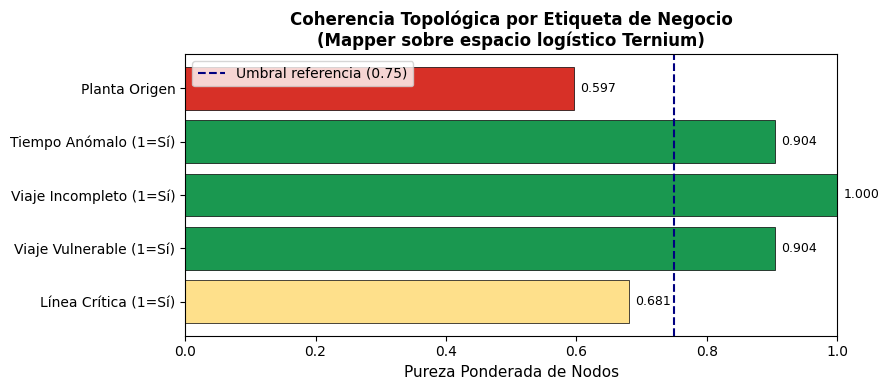

In [ ]:
# ── Visualización de pureza ──
etiq_bin = {k: v for k, v in resultados_pureza.items() if v['pureza'] is not None}

if etiq_bin:
    fig, ax = plt.subplots(figsize=(9, 4))
    nombres = list(etiq_bin.keys())
    purezas = [etiq_bin[n]['pureza'] for n in nombres]
    colores_bar = ['#d73027' if p < 0.6 else '#fee08b' if p < 0.75 else '#1a9850'
                   for p in purezas]

    bars = ax.barh(nombres, purezas, color=colores_bar, edgecolor='black', linewidth=0.5)
    ax.axvline(x=0.75, color='navy', linestyle='--', linewidth=1.5,
               label='Umbral referencia (0.75)')
    ax.set_xlabel('Pureza Ponderada de Nodos', fontsize=11)
    ax.set_title('Coherencia Topológica por Etiqueta de Negocio\n(Mapper sobre espacio logístico Ternium)',
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_xlim(0, 1)

    # Anotar valores
    for bar, val in zip(bars, purezas):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('pureza_nodos_mapper.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Mapper Segmentado por Circuito Crítico

Análisis de la estructura topológica **únicamente dentro de los circuitos críticos** para identificar regímenes internos:

In [ ]:
def mapper_segmento(df_seg, features, nombre_seg, n_cubes=10, overlap=0.4,
                    eps=0.8, min_samples=3, n_umap_neighbors=20):
    """
    Aplica Mapper a un subconjunto del dataset.
    Útil para analizar regímenes dentro de circuitos críticos específicos.
    """
    if len(df_seg) < 50:
        print(f"  {nombre_seg}: muestra insuficiente ({len(df_seg)} puntos), omitiendo.")
        return None, None

    feats_disp = [f for f in features if f in df_seg.columns]
    X = df_seg[feats_disp].fillna(df_seg[feats_disp].median())

    for col in ['TIEMPO_TRANSITO_H', 'N_PESO_NETO', 'TIEMPO_ESPERA_PROG_H']:
        if col in X.columns:
            X[col] = np.log1p(X[col].clip(lower=0))

    X_sc = StandardScaler().fit_transform(X)

    n_neighbors = min(n_umap_neighbors, len(df_seg) - 1)
    lens = umap.UMAP(n_components=2, n_neighbors=n_neighbors,
                     min_dist=0.3, random_state=42).fit_transform(X_sc)

    m = km.KeplerMapper(verbose=0)
    g = m.map(
        lens, X_sc,
        clusterer=DBSCAN(eps=eps, min_samples=min_samples),
        cover=Cover(n_cubes=n_cubes, perc_overlap=overlap)
    )

    fname = f"mapper_{nombre_seg.replace(' ', '_').replace('→','to').replace('[','').replace(']','')[:40]}.html"
    m.visualize(
        g, path_html=fname,
        title=f"Mapper — {nombre_seg}",
        color_values=X_sc[:, 0],
        color_function_name='Tiempo de Tránsito (log)'
    )

    G_nx = nx.Graph(g['links'])
    print(f"  {nombre_seg[:50]:50s} | n={len(df_seg):4d} | nodos={G_nx.number_of_nodes():3d} | aristas={G_nx.number_of_edges():3d}")
    return g, fname


# ── Top circuitos críticos por volumen ──
top_destinos_criticos = (
    df_sample[df_sample['ES_LINEA_CRITICA'] == 1]
    .groupby('DESTINO')
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

print("Top 5 destinos críticos en la muestra:")
for d in top_destinos_criticos:
    n = (df_sample['DESTINO'] == d).sum()
    print(f"  {d}: {n} registros")

print("\nMapper segmentado por destino crítico:")
grafos_segmento = {}
for destino in top_destinos_criticos:
    df_dest = df_sample[df_sample['DESTINO'] == destino].copy()
    g, fname = mapper_segmento(
        df_dest, features_disponibles, destino,
        n_cubes=8, overlap=0.45, eps=0.9, min_samples=3
    )
    if g is not None:
        grafos_segmento[destino] = (g, fname)

Top 5 destinos críticos en la muestra:
  Churubusco: 940 registros
  Juventud: 1208 registros
  Universidad: 822 registros
  CSI Apodaca: 616 registros
  Planos Guerrero: 636 registros

Mapper segmentado por destino crítico:


  Churubusco                                         | n= 940 | nodos= 79 | aristas=183


  Juventud                                           | n=1208 | nodos= 73 | aristas=164


  Universidad                                        | n= 822 | nodos= 76 | aristas=167


  CSI Apodaca                                        | n= 616 | nodos= 56 | aristas=120


  Planos Guerrero                                    | n= 636 | nodos= 64 | aristas=143


In [ ]:
# ── Mostrar el Mapper del circuito crítico más importante ──
if grafos_segmento:
    primer_destino = list(grafos_segmento.keys())[0]
    _, fname_primer = grafos_segmento[primer_destino]
    print(f"Visualizando: {primer_destino}")
    display(IFrame(fname_primer, width=900, height=500))

Visualizando: Churubusco


## 10. Mapper por Ventanas Temporales

¿Cambia la estructura topológica del espacio logístico a lo largo del tiempo? Esto es relevante para responder la Pregunta 2 del reto: ¿las transiciones hacia desabasto son graduales o abruptas?

In [ ]:
# ── Identificar semanas disponibles en la muestra ──
if 'FECHA_SALIDA_ORIGEN' in df_sample.columns:
    df_sample['SEMANA'] = df_sample['FECHA_SALIDA_ORIGEN'].dt.to_period('W').astype(str)
    semanas_disponibles = sorted(df_sample['SEMANA'].dropna().unique())
    print(f"Semanas en la muestra: {len(semanas_disponibles)}")
    print(f"  Desde: {semanas_disponibles[0]} | Hasta: {semanas_disponibles[-1]}")

    # ── Mapper por semana ──
    estadisticas_temporales = []

    print("\nMapper semanal:")
    for semana in semanas_disponibles[:8]:  # primeras 8 semanas
        df_sem = df_sample[df_sample['SEMANA'] == semana].copy()

        if len(df_sem) < 30:
            continue

        feats_disp = [f for f in features_disponibles if f in df_sem.columns]
        X = df_sem[feats_disp].fillna(df_sem[feats_disp].median())
        for col in ['TIEMPO_TRANSITO_H', 'N_PESO_NETO']:
            if col in X.columns:
                X[col] = np.log1p(X[col].clip(lower=0))
        X_sc = StandardScaler().fit_transform(X)

        n_nb = min(15, len(df_sem) - 1)
        lens_sem = umap.UMAP(n_components=2, n_neighbors=n_nb,
                             min_dist=0.3, random_state=42).fit_transform(X_sc)
        m_sem = km.KeplerMapper(verbose=0)
        g_sem = m_sem.map(
            lens_sem, X_sc,
            clusterer=DBSCAN(eps=0.8, min_samples=3),
            cover=Cover(n_cubes=8, perc_overlap=0.4)
        )
        G_sem = nx.Graph(g_sem['links'])

        estadisticas_temporales.append({
            'semana': semana,
            'n_viajes': len(df_sem),
            'pct_criticos': df_sem['ES_LINEA_CRITICA'].mean(),
            'pct_vulnerables': df_sem['VIAJE_VULNERABLE'].mean(),
            'tt_mediana': df_sem['TIEMPO_TRANSITO_H'].median(),
            'nodos_mapper': G_sem.number_of_nodes(),
            'aristas_mapper': G_sem.number_of_edges(),
            'componentes_mapper': nx.number_connected_components(G_sem) if G_sem.number_of_nodes() > 0 else 0,
        })
        print(f"  {semana} | n={len(df_sem):4d} | nodos={G_sem.number_of_nodes():3d} | vulnerables={df_sem['VIAJE_VULNERABLE'].mean():.1%}")

    df_temporal = pd.DataFrame(estadisticas_temporales)

else:
    print("FECHA_SALIDA_ORIGEN no disponible — análisis temporal omitido")
    df_temporal = pd.DataFrame()

Semanas en la muestra: 29
  Desde: 2025-12-29/2026-01-04 | Hasta: 2026-11-30/2026-12-06

Mapper semanal:


  2025-12-29/2026-01-04 | n= 153 | nodos= 40 | vulnerables=5.9%


  2026-01-05/2026-01-11 | n=  50 | nodos=  6 | vulnerables=14.0%


  2026-01-12/2026-01-18 | n= 428 | nodos= 49 | vulnerables=14.3%


  2026-01-19/2026-01-25 | n= 539 | nodos= 71 | vulnerables=9.5%


  2026-01-26/2026-02-01 | n= 399 | nodos= 76 | vulnerables=9.8%


  2026-02-02/2026-02-08 | n= 157 | nodos= 39 | vulnerables=7.0%


  2026-02-09/2026-02-15 | n= 211 | nodos= 50 | vulnerables=20.4%


  2026-02-16/2026-02-22 | n= 530 | nodos= 72 | vulnerables=14.9%


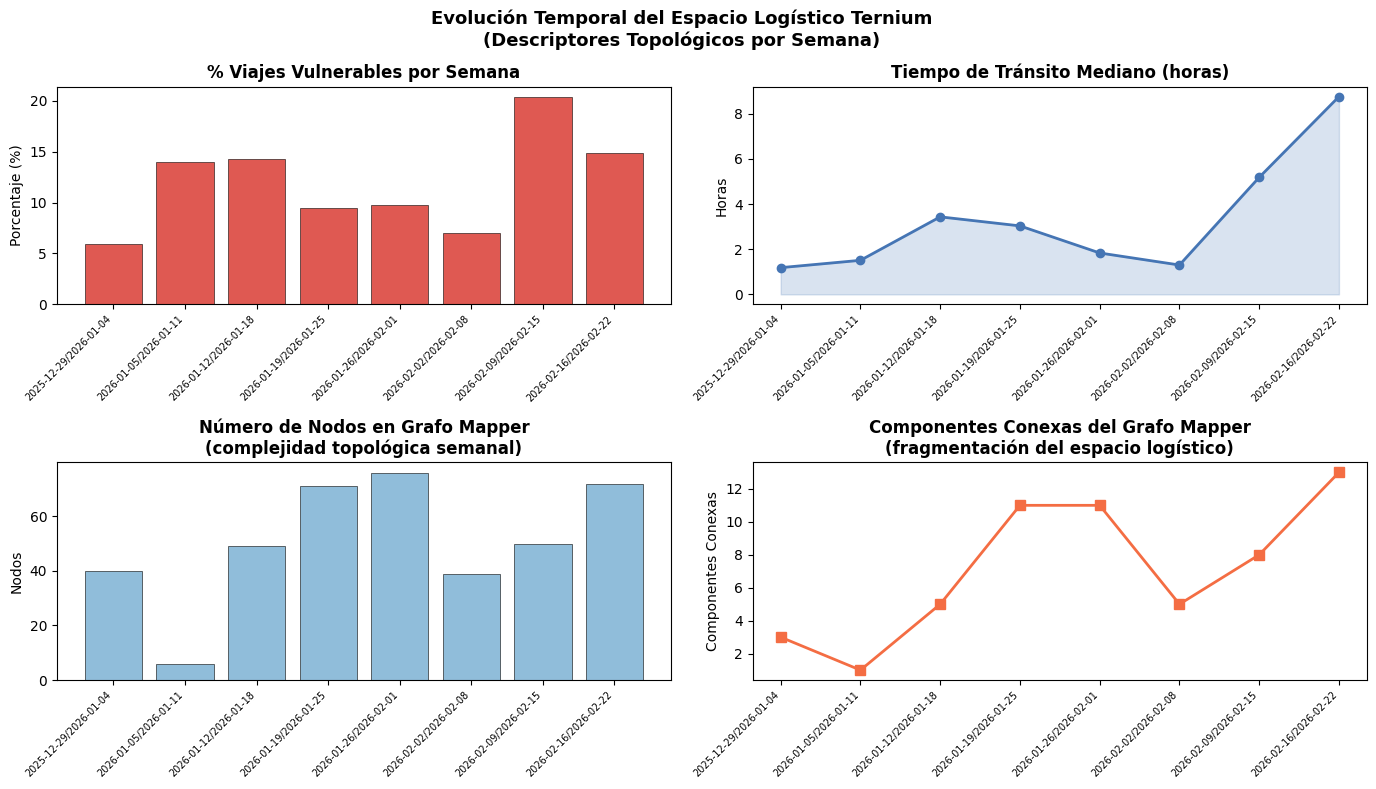


→ Dashboard guardado: evolucion_temporal_mapper.png


In [ ]:
# ── Dashboard temporal ──
if not df_temporal.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Evolución Temporal del Espacio Logístico Ternium\n(Descriptores Topológicos por Semana)',
                 fontsize=13, fontweight='bold')

    semanas_idx = range(len(df_temporal))
    labels_x = df_temporal['semana'].tolist()

    # Panel 1: Viajes vulnerables
    ax = axes[0, 0]
    ax.bar(semanas_idx, df_temporal['pct_vulnerables'] * 100,
           color='#d73027', alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title('% Viajes Vulnerables por Semana', fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xticks(semanas_idx)
    ax.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=7)

    # Panel 2: Tiempo mediano de tránsito
    ax = axes[0, 1]
    ax.plot(semanas_idx, df_temporal['tt_mediana'], 'o-',
            color='#4575b4', linewidth=2, markersize=6)
    ax.fill_between(semanas_idx, df_temporal['tt_mediana'],
                    alpha=0.2, color='#4575b4')
    ax.set_title('Tiempo de Tránsito Mediano (horas)', fontweight='bold')
    ax.set_ylabel('Horas')
    ax.set_xticks(semanas_idx)
    ax.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=7)

    # Panel 3: Número de nodos Mapper
    ax = axes[1, 0]
    ax.bar(semanas_idx, df_temporal['nodos_mapper'],
           color='#74add1', alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title('Número de Nodos en Grafo Mapper\n(complejidad topológica semanal)',
                 fontweight='bold')
    ax.set_ylabel('Nodos')
    ax.set_xticks(semanas_idx)
    ax.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=7)

    # Panel 4: Componentes conexas
    ax = axes[1, 1]
    ax.plot(semanas_idx, df_temporal['componentes_mapper'], 's-',
            color='#f46d43', linewidth=2, markersize=7)
    ax.set_title('Componentes Conexas del Grafo Mapper\n(fragmentación del espacio logístico)',
                 fontweight='bold')
    ax.set_ylabel('Componentes Conexas')
    ax.set_xticks(semanas_idx)
    ax.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.savefig('evolucion_temporal_mapper.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n→ Dashboard guardado: evolucion_temporal_mapper.png")

## 11. Visualización Estática del Grafo Mapper (NetworkX)

Alternativa a la visualización HTML — útil para incluir en el reporte LaTeX:

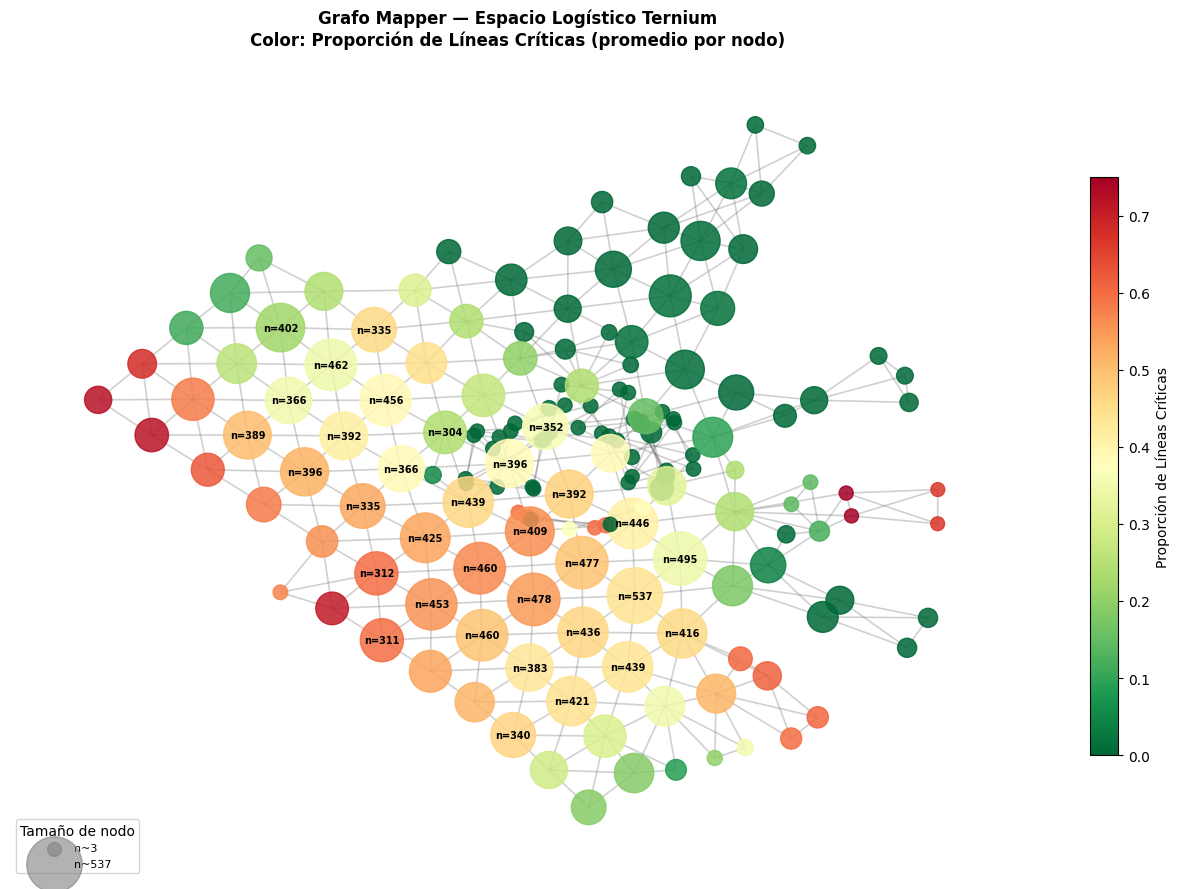

→ Guardado: grafo_mapper_linea_critica.png


In [ ]:
def visualizar_grafo_estatico(graph, df_sample, etiqueta_col, titulo_etiqueta,
                               cmap_name='RdYlGn_r', fname='grafo_mapper.png'):
    """
    Dibuja el grafo Mapper usando NetworkX con layout spring.
    El color de cada nodo es el promedio de la etiqueta en ese nodo.
    El tamaño del nodo es proporcional a la cantidad de puntos que contiene.
    """
    G_nx = nx.Graph()
    nodos = list(graph['nodes'].keys())
    tamaños = []
    valores_color = []
    etiqueta_vals = df_sample[etiqueta_col].values

    for nodo in nodos:
        idx = graph['nodes'][nodo]
        G_nx.add_node(nodo)
        tamaños.append(len(idx))
        valores_color.append(np.nanmean(etiqueta_vals[idx]))

    for nodo, vecinos in graph['links'].items():
        for v in vecinos:
            G_nx.add_edge(nodo, v)

    if G_nx.number_of_nodes() == 0:
        print("Grafo vacío — omitiendo visualización")
        return

    # Normalizar tamaños
    t_arr = np.array(tamaños)
    t_norm = 100 + 1500 * (t_arr - t_arr.min()) / (t_arr.max() - t_arr.min() + 1)

    # Normalizar colores
    v_arr = np.array(valores_color)
    v_norm = (v_arr - v_arr.min()) / (v_arr.max() - v_arr.min() + 1e-8)
    cmap = plt.get_cmap(cmap_name)
    node_colors = [cmap(v) for v in v_norm]

    fig, ax = plt.subplots(figsize=(13, 9))

    # Intentar layout Kamada-Kawai (mejor para grafos logísticos)
    try:
        pos = nx.kamada_kawai_layout(G_nx)
    except Exception:
        pos = nx.spring_layout(G_nx, seed=42, k=2)

    # Dibujar aristas
    nx.draw_networkx_edges(G_nx, pos, ax=ax, alpha=0.3,
                           edge_color='#666666', width=1.2)

    # Dibujar nodos
    sc = nx.draw_networkx_nodes(G_nx, pos, ax=ax,
                                 node_size=t_norm,
                                 node_color=node_colors,
                                 alpha=0.85)

    # Anotar nodos grandes
    threshold_size = np.percentile(t_arr, 80)
    for nodo, (x, y), tam in zip(nodos, [pos[n] for n in nodos], t_arr):
        if tam >= threshold_size:
            ax.annotate(f'n={tam}', (x, y), ha='center', va='center',
                        fontsize=7, fontweight='bold', color='black')

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=v_arr.min(), vmax=v_arr.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=titulo_etiqueta, shrink=0.7)

    ax.set_title(f'Grafo Mapper — Espacio Logístico Ternium\nColor: {titulo_etiqueta} (promedio por nodo)',
                 fontsize=12, fontweight='bold')
    ax.axis('off')

    # Leyenda de tamaño
    for tam_ref, label_ref in [(t_arr.min(), 'Mín'), (t_arr.max(), 'Máx')]:
        ax.scatter([], [], s=100 + 1500*(tam_ref - t_arr.min())/(t_arr.max()-t_arr.min()+1),
                   c='grey', alpha=0.6, label=f'n~{int(tam_ref)}')
    ax.legend(title='Tamaño de nodo', loc='lower left', fontsize=8)

    plt.tight_layout()
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"→ Guardado: {fname}")


# ── Grafo coloreado por Línea Crítica ──
visualizar_grafo_estatico(
    graph, df_sample,
    etiqueta_col='ES_LINEA_CRITICA',
    titulo_etiqueta='Proporción de Líneas Críticas',
    cmap_name='RdYlGn_r',
    fname='grafo_mapper_linea_critica.png'
)

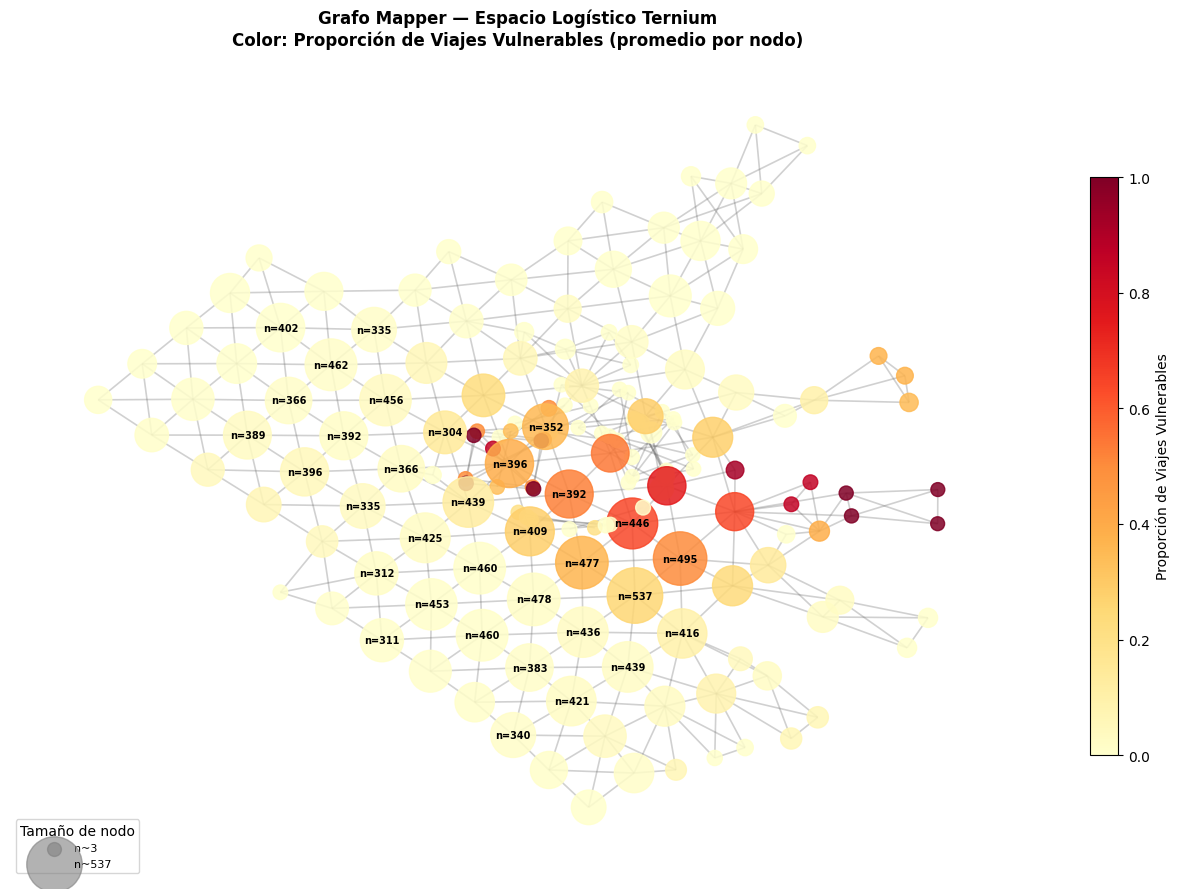

→ Guardado: grafo_mapper_vulnerabilidad.png


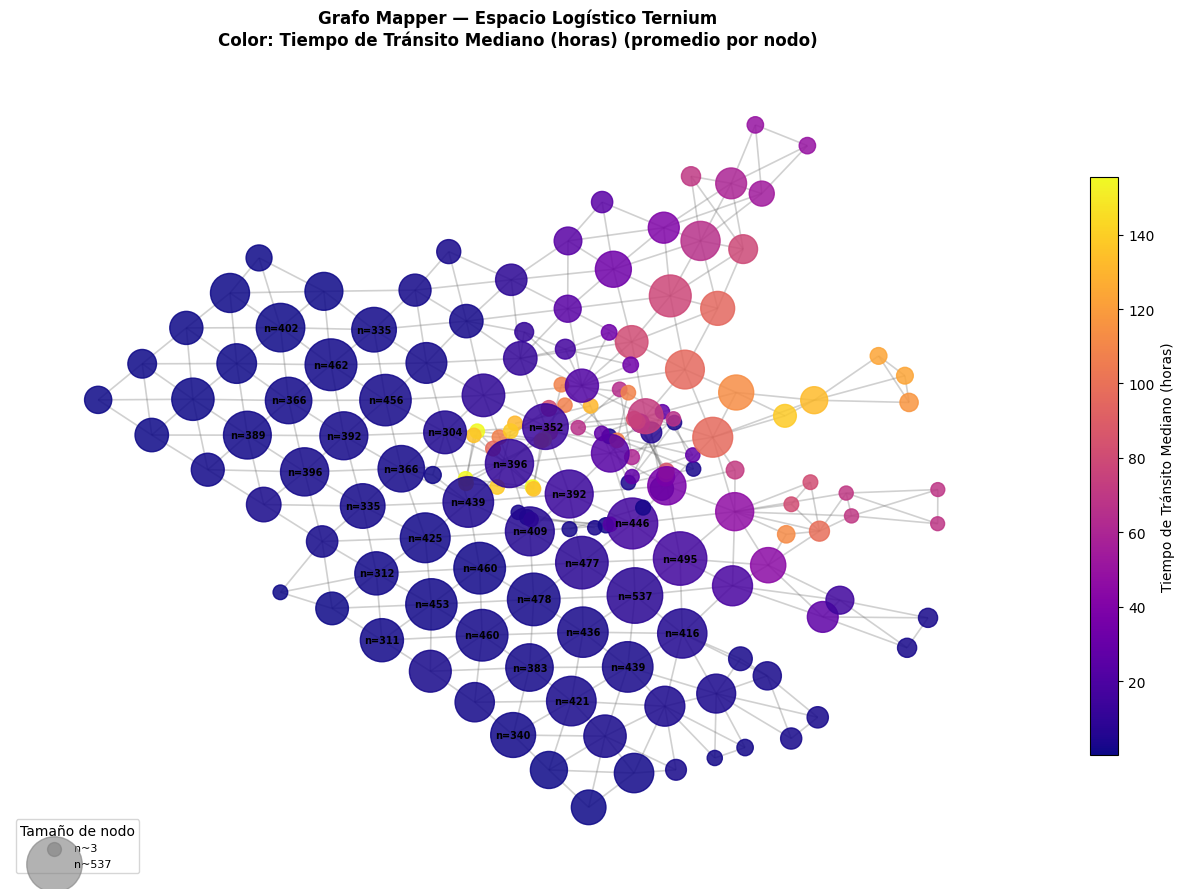

→ Guardado: grafo_mapper_tiempo.png


In [ ]:
# ── Grafo coloreado por Viaje Vulnerable ──
visualizar_grafo_estatico(
    graph, df_sample,
    etiqueta_col='VIAJE_VULNERABLE',
    titulo_etiqueta='Proporción de Viajes Vulnerables',
    cmap_name='YlOrRd',
    fname='grafo_mapper_vulnerabilidad.png'
)

# ── Grafo coloreado por Tiempo de Tránsito ──
visualizar_grafo_estatico(
    graph, df_sample,
    etiqueta_col='TIEMPO_TRANSITO_H',
    titulo_etiqueta='Tiempo de Tránsito Mediano (horas)',
    cmap_name='plasma',
    fname='grafo_mapper_tiempo.png'
)

## 12. Análisis de Nodos Críticos y Anomalías

Identificar los nodos del grafo Mapper que concentran mayor riesgo operativo:

In [ ]:
def analizar_nodos_criticos(graph, df_sample, top_n=10):
    """
    Extrae los nodos del grafo Mapper con mayor proporción de
    viajes vulnerables a líneas críticas.
    Retorna un DataFrame de nodos ordenados por riesgo logístico.
    """
    registros = []

    for nodo, idx in graph['nodes'].items():
        if len(idx) < 3:
            continue
        subdf = df_sample.iloc[idx]

        # Destinos más frecuentes en este nodo
        top_destino = subdf['DESTINO'].value_counts().index[0] if 'DESTINO' in subdf else 'N/A'
        top_camion = subdf['NOMBRE_TIPO_CAMION'].value_counts().index[0] if 'NOMBRE_TIPO_CAMION' in subdf else 'N/A'

        registros.append({
            'nodo': nodo,
            'n_viajes': len(idx),
            'pct_criticos': subdf['ES_LINEA_CRITICA'].mean(),
            'pct_vulnerables': subdf['VIAJE_VULNERABLE'].mean(),
            'tt_mediana_h': subdf['TIEMPO_TRANSITO_H'].median(),
            'tt_max_h': subdf['TIEMPO_TRANSITO_H'].max(),
            'top_destino': top_destino,
            'top_camion': top_camion[:30],
            'score_riesgo': (subdf['ES_LINEA_CRITICA'].mean() * 0.5 +
                             subdf['VIAJE_VULNERABLE'].mean() * 0.5)
        })

    df_nodos = pd.DataFrame(registros).sort_values('score_riesgo', ascending=False)
    return df_nodos.head(top_n)


df_nodos_criticos = analizar_nodos_criticos(graph, df_sample, top_n=15)

print("═══════════════════════════════════════════════════════════════")
print("TOP NODOS DE MAYOR RIESGO LOGÍSTICO EN EL GRAFO MAPPER")
print("═══════════════════════════════════════════════════════════════")
display(df_nodos_criticos[[
    'nodo', 'n_viajes', 'pct_criticos', 'pct_vulnerables',
    'tt_mediana_h', 'top_destino', 'score_riesgo'
]].to_string(index=False))

═══════════════════════════════════════════════════════════════
TOP NODOS DE MAYOR RIESGO LOGÍSTICO EN EL GRAFO MAPPER
═══════════════════════════════════════════════════════════════


'           nodo  n_viajes  pct_criticos  pct_vulnerables  tt_mediana_h top_destino  score_riesgo\ncube39_cluster1         4      0.750000         1.000000     70.183333  Churubusco      0.875000\ncube29_cluster1         4      0.750000         1.000000     70.183333  Churubusco      0.875000\ncube40_cluster1         3      0.666667         1.000000     67.816667  Churubusco      0.833333\ncube30_cluster2         3      0.666667         1.000000     67.816667  Churubusco      0.833333\ncube30_cluster0        25      0.240000         0.920000     66.933333 CSC Apodaca      0.580000\ncube39_cluster0       237      0.316456         0.746835     33.883333 CSC Apodaca      0.531646\ncube51_cluster0       446      0.412556         0.641256     11.533333  Churubusco      0.526906\ncube41_cluster3         5      0.000000         1.000000    142.616667 CEDI México      0.500000\ncube31_cluster3         5      0.000000         1.000000    142.616667 CEDI México      0.500000\ncube30_cluster6    

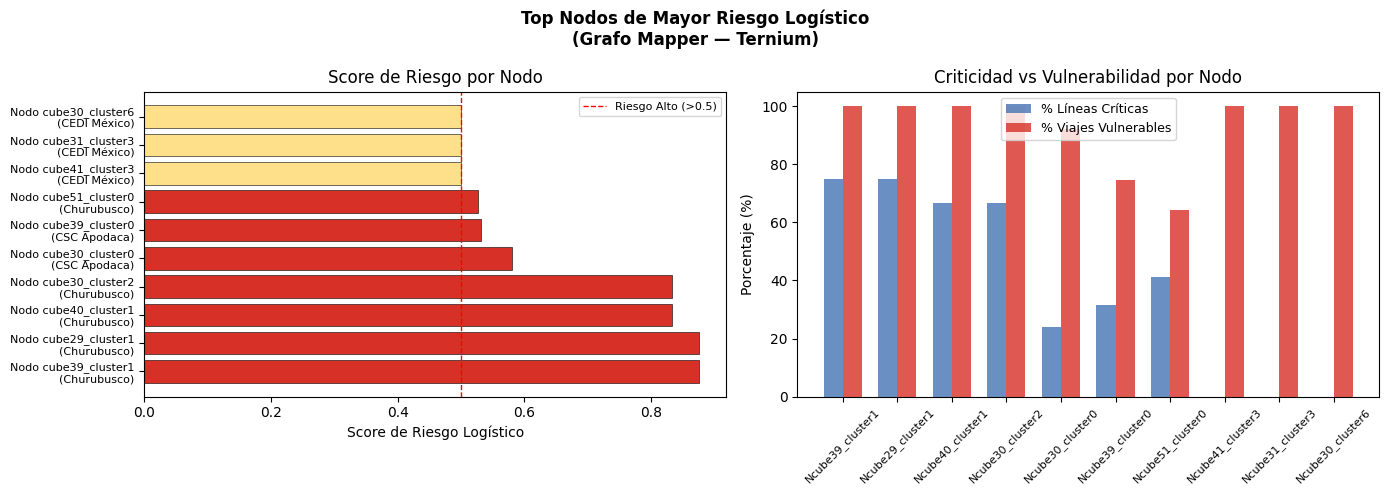

In [ ]:
# ── Dashboard de nodos de riesgo ──
if not df_nodos_criticos.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Top Nodos de Mayor Riesgo Logístico\n(Grafo Mapper — Ternium)',
                 fontsize=12, fontweight='bold')

    top10 = df_nodos_criticos.head(10)
    nodo_labels = [f"Nodo {r['nodo']}\n({r['top_destino'][:20]})" for _, r in top10.iterrows()]

    # Panel 1: Score de riesgo
    ax = axes[0]
    colores_risk = ['#d73027' if s > 0.5 else '#fee08b' if s > 0.3 else '#91bfdb'
                    for s in top10['score_riesgo']]
    ax.barh(range(len(top10)), top10['score_riesgo'], color=colores_risk,
            edgecolor='black', linewidth=0.4)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(nodo_labels, fontsize=8)
    ax.set_xlabel('Score de Riesgo Logístico')
    ax.set_title('Score de Riesgo por Nodo')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Riesgo Alto (>0.5)')
    ax.legend(fontsize=8)

    # Panel 2: Composición % críticos vs vulnerables
    ax = axes[1]
    x = np.arange(len(top10))
    w = 0.35
    ax.bar(x - w/2, top10['pct_criticos'] * 100, w, label='% Líneas Críticas',
           color='#4575b4', alpha=0.8)
    ax.bar(x + w/2, top10['pct_vulnerables'] * 100, w, label='% Viajes Vulnerables',
           color='#d73027', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"N{r['nodo']}" for _, r in top10.iterrows()],
                        fontsize=8, rotation=45)
    ax.set_ylabel('Porcentaje (%)')
    ax.set_title('Criticidad vs Vulnerabilidad por Nodo')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('nodos_criticos_mapper.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Homología Persistente — Complemento al Mapper

Diagrama de persistencia del espacio logístico completo (muestra de 3000 puntos):

Calculando homología persistente (muestra de 3000 puntos)...


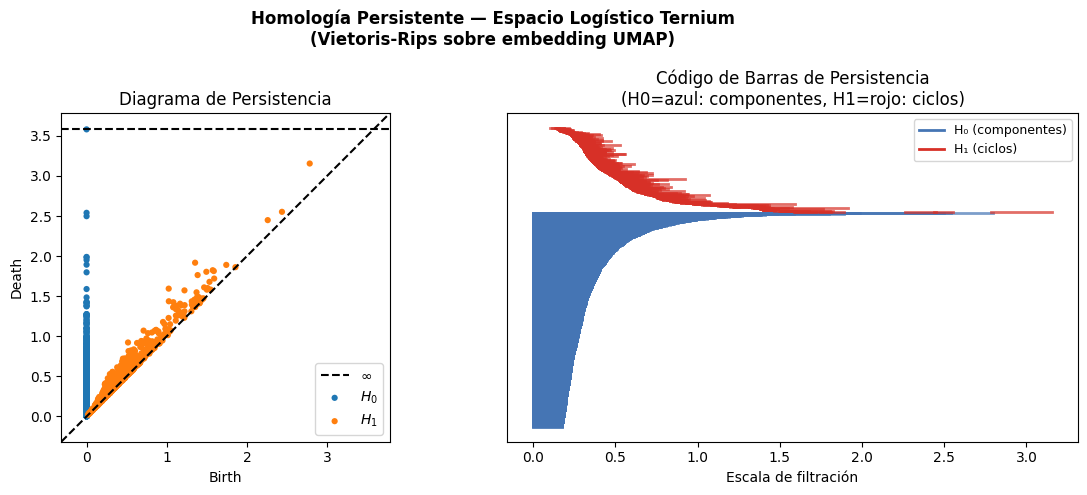


H0 (componentes): 2981 puntos | persistencia máx finita: 2.540
H1 (ciclos):       1179 puntos | persistencia máx: 0.570
Ciclos significativos (persistencia > mediana): 589


In [ ]:
print("Calculando homología persistente (muestra de 3000 puntos)...")

# Subsample para homología (más costoso computacionalmente que Mapper)
# ===================== ARREGLO #6: homologia sobre el espacio real =====================
# ANTES: calculaba ripser sobre el EMBEDDING UMAP 2D (X_umap). UMAP distorsiona
#        distancias y crea agujeros artificiales -> los "ciclos H1" eran artefactos
#        de UMAP, no topologia real de los datos.
#   X_hp = X_umap[idx_hp]
# AHORA: ripser sobre el ESPACIO DE FEATURES estandarizado (X_scaled), donde vive la
#        geometria real (igual que en la Actividad 2).
idx_hp = np.random.choice(len(X_scaled), size=min(3000, len(X_scaled)), replace=False)
X_hp = X_scaled[idx_hp]
# ======================================================================================

diagrams = ripser(X_hp, maxdim=1)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Homología Persistente — Espacio Logístico Ternium\n(Vietoris-Rips sobre embedding UMAP)',
             fontsize=12, fontweight='bold')

# Diagrama de persistencia
plot_diagrams(diagrams, ax=axes[0], show=False)
axes[0].set_title('Diagrama de Persistencia')

# Código de barras (barcode)
ax = axes[1]
colores_dim = {0: '#4575b4', 1: '#d73027'}
y_offset = 0
for dim, dgm in enumerate(diagrams):
    if dim > 1:
        break
    # Filtrar puntos alejados de la diagonal
    persistencia = dgm[:, 1] - dgm[:, 0]
    mask = persistencia > np.percentile(persistencia[persistencia < np.inf], 50)
    dgm_filt = dgm[mask]
    for i, (birth, death) in enumerate(dgm_filt):
        if death == np.inf:
            death = dgm_filt[dgm_filt[:, 1] < np.inf, 1].max() * 1.1 if any(dgm_filt[:, 1] < np.inf) else birth + 1
        ax.plot([birth, death], [y_offset + i, y_offset + i],
                color=colores_dim[dim], linewidth=2, alpha=0.7)
    y_offset += len(dgm_filt) + 2

ax.set_xlabel('Escala de filtración')
ax.set_title('Código de Barras de Persistencia\n(H0=azul: componentes, H1=rojo: ciclos)')
ax.set_yticks([])

from matplotlib.lines import Line2D
leyenda = [Line2D([0], [0], color='#4575b4', linewidth=2, label='H₀ (componentes)'),
           Line2D([0], [0], color='#d73027', linewidth=2, label='H₁ (ciclos)')]
ax.legend(handles=leyenda, fontsize=9)

plt.tight_layout()
plt.savefig('homologia_persistente_ternium.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas
pers_h0 = diagrams[0][:, 1] - diagrams[0][:, 0]
pers_h1 = diagrams[1][:, 1] - diagrams[1][:, 0]
print(f"\nH0 (componentes): {len(diagrams[0])} puntos | persistencia máx finita: {pers_h0[pers_h0 < np.inf].max():.3f}")
print(f"H1 (ciclos):       {len(diagrams[1])} puntos | persistencia máx: {pers_h1.max():.3f}")
print(f"Ciclos significativos (persistencia > mediana): {(pers_h1 > np.median(pers_h1)).sum()}")

## 14. Resumen de Hallazgos e Implicaciones para el LNO

Interpretación automática de los resultados topológicos:

In [ ]:
print("═══════════════════════════════════════════════════════════════")
print("RESUMEN DE HALLAZGOS TOPOLÓGICOS — RETO TERNIUM")
print("═══════════════════════════════════════════════════════════════")

n_nodos = G.number_of_nodes()
n_aristas = G.number_of_edges()
n_comp = nx.number_connected_components(G) if n_nodos > 0 else 0
grado_prom = sum(dict(G.degree()).values()) / n_nodos if n_nodos > 0 else 0

print(f"""
GRAFO MAPPER PRINCIPAL
  · Nodos: {n_nodos} | Aristas: {n_aristas} | Componentes: {n_comp}
  · Grado promedio: {grado_prom:.2f}
  · Lente: UMAP (n_neighbors=40, min_dist=0.4)
  · Cobertura: {N_CUBES} cubos, {OVERLAP*100:.0f}% solapamiento
  · Clustering local: DBSCAN (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN})

INTERPRETACIÓN TOPOLÓGICA
  · {n_comp} componente(s) conexa(s) → el espacio logístico presenta {'heterogeneidad significativa' if n_comp > 3 else 'estructura relativamente cohesionada'}
  · {'Múltiples' if n_nodos > 20 else 'Pocos'} regímenes operativos detectados
  · Viajes vulnerables (tiempo anómalo o incompleto): {df_sample['VIAJE_VULNERABLE'].mean()*100:.1f}%

IMPLICACIONES PARA EL LNO
  1. Los nodos con alta proporción de líneas críticas Y viajes vulnerables
     corresponden a circuitos que deben priorizarse en el LNO.
  2. La {'fragmentación' if n_comp > 3 else 'cohesión'} del grafo sugiere que
     {'existen microregímenes operativos diferenciados que el LNO debería tratar por separado.' if n_comp > 3 else 'los circuitos comparten comportamiento operativo compatible con reglas globales en el LNO.'}
  3. Los ciclos topológicos en H1 evidencian transiciones recurrentes entre
     regímenes (normal ↔ retraso ↔ recuperación) — el LNO podría parametrizar
     umbrales de alerta temprana basados en la escala de filtración de estos ciclos.
""")

print("═══════════════════════════════════════════════════════════════")
print("ARCHIVOS GENERADOS")
print("═══════════════════════════════════════════════════════════════")
archivos = [
    ("mapper_tiempo_transito.html", "Mapper interactivo — Tiempo de Tránsito"),
    ("mapper_linea_critica.html",   "Mapper interactivo — Línea Crítica"),
    ("mapper_viaje_vulnerable.html","Mapper interactivo — Viaje Vulnerable"),
    ("mapper_tipo_camion.html",     "Mapper interactivo — Tipo de Camión"),
    ("grafo_mapper_linea_critica.png",  "Grafo estático — Línea Crítica (reporte)"),
    ("grafo_mapper_vulnerabilidad.png", "Grafo estático — Vulnerabilidad"),
    ("grafo_mapper_tiempo.png",         "Grafo estático — Tiempo de Tránsito"),
    ("nodos_criticos_mapper.png",       "Dashboard — Nodos de mayor riesgo"),
    ("homologia_persistente_ternium.png","Diagrama de persistencia"),
    ("evolucion_temporal_mapper.png",   "Dashboard — Evolución temporal"),
    ("lentes_comparacion.png",          "Comparación de lentes UMAP/PCA"),
    ("pureza_nodos_mapper.png",         "Pureza de nodos por etiqueta"),
]
for archivo, descripcion in archivos:
    import os
    existe = "✓" if os.path.exists(archivo) else "○"
    print(f"  {existe} {archivo:50s} — {descripcion}")

═══════════════════════════════════════════════════════════════
RESUMEN DE HALLAZGOS TOPOLÓGICOS — RETO TERNIUM
═══════════════════════════════════════════════════════════════

GRAFO MAPPER PRINCIPAL
  · Nodos: 165 | Aristas: 405 | Componentes: 19
  · Grado promedio: 4.91
  · Lente: UMAP (n_neighbors=40, min_dist=0.4)
  · Cobertura: 12 cubos, 45% solapamiento
  · Clustering local: DBSCAN (eps=0.8, min_samples=5)

INTERPRETACIÓN TOPOLÓGICA
  · 19 componente(s) conexa(s) → el espacio logístico presenta heterogeneidad significativa
  · Múltiples regímenes operativos detectados
  · Viajes vulnerables (tiempo anómalo o incompleto): 11.4%

IMPLICACIONES PARA EL LNO
  1. Los nodos con alta proporción de líneas críticas Y viajes vulnerables
     corresponden a circuitos que deben priorizarse en el LNO.
  2. La fragmentación del grafo sugiere que
     existen microregímenes operativos diferenciados que el LNO debería tratar por separado.
  3. Los ciclos topológicos en H1 evidencian transiciones

---

## Notas para el Equipo

### Ajuste de parámetros
Los parámetros más importantes del Mapper están declarados en la Sección 7:
- **`N_CUBES`** (12): más cubos → mayor resolución pero grafos más complejos. Probar 8-15.
- **`OVERLAP`** (0.45): mayor solapamiento → más conexiones entre regímenes. Probar 0.3-0.6.
- **`DBSCAN_EPS`** (0.8): controla la granularidad del clustering local. Si el grafo tiene demasiados nodos pequeños, aumentar a 1.2.
- **`SAMPLE_SIZE`** (8000): con más RAM en Colab Pro se puede subir a 15,000-20,000.

### Cómo incluir los grafos estáticos en LaTeX
```latex
\begin{figure}[h]
  \centering
  \includegraphics[width=0.9\textwidth]{grafo_mapper_linea_critica.png}
  \caption{Grafo Mapper del espacio logístico de Ternium coloreado por
  proporción de líneas críticas. Cada nodo agrupa viajes con características
  operativas similares; el tamaño es proporcional al número de viajes.}
  \label{fig:mapper_critico}
\end{figure}
```

### Preguntas de investigación cubiertas
- **Pregunta 1** (regiones vacías): Los componentes conexas del grafo H0 revelan dónde el espacio logístico tiene discontinuidades.
- **Pregunta 2** (filamentos vs saltos): La estructura del grafo Mapper (filamentos continuos vs ramas separadas) responde si la transición a desabasto es gradual o abrupta.
- **Pregunta 3** (firmas topológicas): Los grafos segmentados por circuito y la distancia de Wasserstein cuantifican si distintos circuitos tienen geometrías similares.